## Libraries and Packages

In [ ]:
## conda env (kernel): faiss_py10

import torch
import torch.nn as nn

import faiss
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import glob 
from tqdm import tqdm 
import matplotlib.pyplot as plt 
import os 

import warnings
warnings.filterwarnings("ignore")

/home/guoj5/anaconda3/envs/faiss_py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guoj5/anaconda3/envs/faiss_py10/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Setup (Define Here)

In [ ]:
pretrained_weight = '/home/guoj5/checkpoints/DeepAndes/teacher_checkpoint.pth'  # Path to pre-trained checkpoint
device = torch.device("cuda:0")                                                 # Specify GPU index 
path_to_all_images = '/data/guoj5/testing1/*.npy'                               # Path to all database images
number_to_retrieve = 10                                                         # Top-k retrieval ranked by cosine similarity

query_image_path = '/data/guoj5/testing1/CLS1-7760-223.npy'                     # A query image for retrieval


# image to embedding help func
def extract_features(image_path, model, transform):
    """Extract image features using the provided model."""
    image = np.load(image_path)
    input_tensor = transform(image=image)['image'].unsqueeze(0) # unsqueeze when batch size 1 
    
    # torch uint8 -> torch.float32
    if input_tensor.dtype == torch.uint8:
        input_tensor = input_tensor.float() / 255.0  # Convert to float and normalize

    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        features = model(input_tensor)
    return features.cpu().detach().numpy().squeeze()

## Load pre-trained backbone

In [3]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
teacher_checkpoint = pretrained_weight # path to .pth 
pretrained_dict = torch.load(teacher_checkpoint)
checkpoint_key = 'teacher'
new_state_dict = {}
for k, v in pretrained_dict[checkpoint_key].items():
    if 'dino_head' in k:
        print(f'{k} not used')

    elif 'ibot_head' in k:
        print(f'{k} not used')
    else:
        new_key = k.replace('backbone.', '')
        new_state_dict[new_key] = v
#change shape of pos_embed, shape depending on vits or vitg, or  vitl
pos_embed = nn.Parameter(torch.zeros(1, 257, 1024))
model.pos_embed = pos_embed

new_patch_embed = model.patch_embed
new_patch_embed.proj = nn.Conv2d(
    in_channels=8,  # Updated for 8 input bands
    out_channels=new_patch_embed.proj.out_channels,
    kernel_size=new_patch_embed.proj.kernel_size,
    stride=new_patch_embed.proj.stride,
    padding=new_patch_embed.proj.padding,
)
# Replace the old PatchEmbed with the updated one
model.patch_embed = new_patch_embed


# load state dict
model.load_state_dict(new_state_dict, strict=True)
model.eval()

Using cache found in /home/guoj5/.cache/torch/hub/facebookresearch_dinov2_main


dino_head.mlp.0.weight not used
dino_head.mlp.0.bias not used
dino_head.mlp.2.weight not used
dino_head.mlp.2.bias not used
dino_head.mlp.4.weight not used
dino_head.mlp.4.bias not used
dino_head.last_layer.weight_g not used
dino_head.last_layer.weight_v not used
ibot_head.mlp.0.weight not used
ibot_head.mlp.0.bias not used
ibot_head.mlp.2.weight not used
ibot_head.mlp.2.bias not used
ibot_head.mlp.4.weight not used
ibot_head.mlp.4.bias not used
ibot_head.last_layer.weight_g not used
ibot_head.last_layer.weight_v not used


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(8, 1024, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-23): 24 x NestedTensorBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((1024,), eps=1e-06, element

## Create faiss index database

In [4]:
 # 1. Move the model to GPU
model = model.to(device)        


# 2. Define a Transformation Pipeline for Images
resize_transform = A.Compose([
    A.Resize(224, 224),     # Target size (H, W)
    ToTensorV2()            # Converts to PyTorch tensor
])


# 3. Create a Dataset of Image Features
image_paths = glob.glob(path_to_all_images)

features = [extract_features(img, model, resize_transform) for img in tqdm(image_paths, desc="FAISS ID CREATE:")]
features = np.array(features).astype('float32')  # Convert to float32 (required by FAISS)

# 4. Normalize the Features (Required for Cosine Similarity)
features_normalized = features / np.linalg.norm(features, axis=1, keepdims=True)

# 5. Create a FAISS Index for Inner Product (Cosine Similarity)
dimension = features_normalized.shape[1]     # Dimension of the feature vectors
index = faiss.IndexFlatIP(dimension)         # Inner product index
index.add(features_normalized)               # Add normalized features to the index

print(f"Number of images indexed: {index.ntotal}")

FAISS ID CREATE:: 100%|██████████| 8019/8019 [01:33<00:00, 85.56it/s]

Number of images indexed: 8019


## Query image

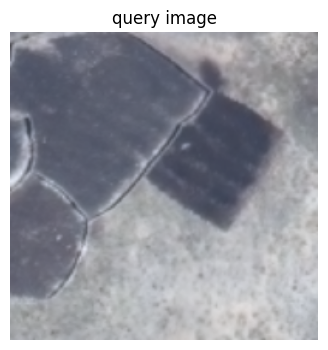

In [5]:
query_feature = extract_features(query_image_path, model, resize_transform).astype('float32')
query_feature_normalized = query_feature / np.linalg.norm(query_feature)  # Normalize query

plt.figure(figsize=(4,4))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()

## Retrieve Top-k images from database

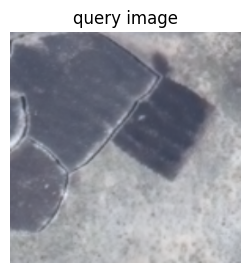

Top 10 similar images


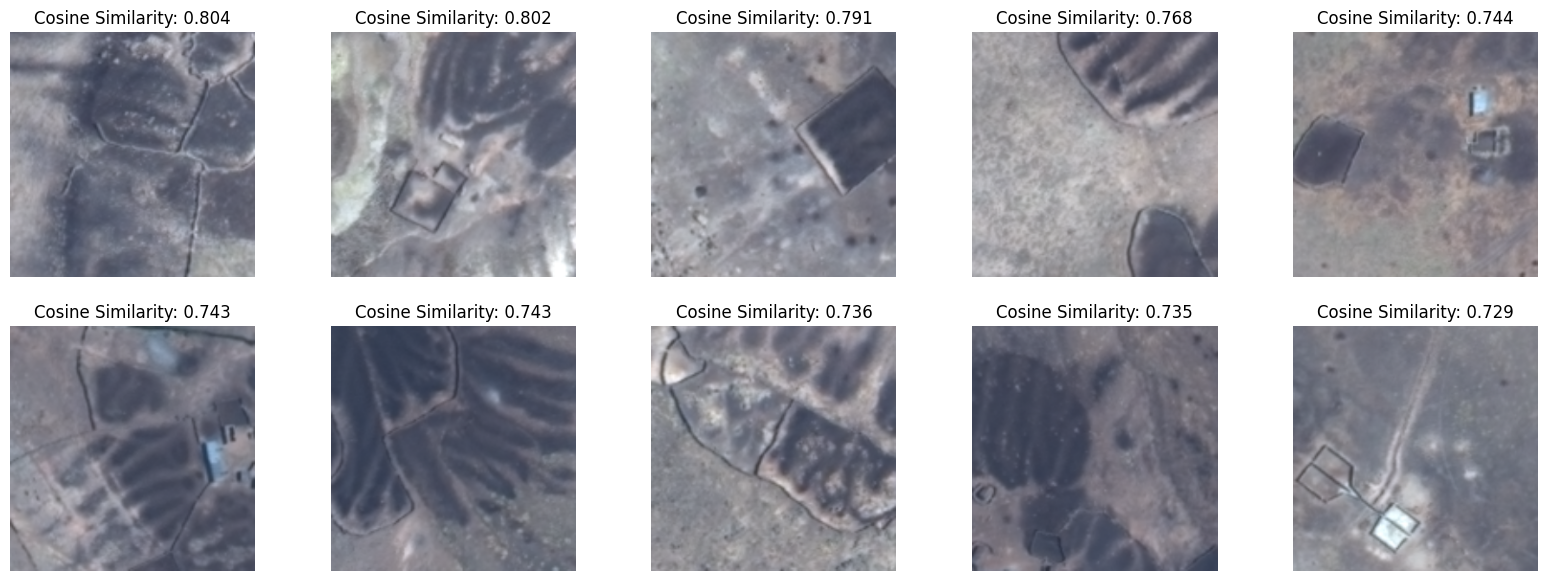

In [6]:
 #  number_to_retrieve + 1 of similar images to retrieve (including the query Image itself)
distances, indices = index.search(np.expand_dims(query_feature_normalized, axis=0), number_to_retrieve + 1)


# 7. Display Results

# dispaly query image input 
plt.figure(figsize=(3,3))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()


# display retrieved top-k images (k =10 means number_to_retrieve = 10)
print(f'Top {number_to_retrieve} similar images')
fig, axes = plt.subplots(2, 5, figsize=(20, 7))  # Adjust col number based on k (number_to_retrieve)
count = 0 
for idx, dist in zip(indices[0][1::], distances[0][1::]):
    # Load and display the image using channels 4, 2, and 1 as RGB for visualization purposes only
    img = np.load(image_paths[idx])[:, :, (4, 2, 1)]
    axes[count//5][count % 5].imshow(img)
    axes[count//5][count % 5].set_title(f'Cosine Similarity: {dist:.3f}')
    axes[count//5][count % 5].axis('off')  
    count +=1 